1. Loading Econometric Dataset...
2. Preparing Variables for Regression...
3. Fitting OLS Regression Model...

   SECURITY SECTOR ACCOUNTABILITY AND CITIZEN TRUST: OLS REGRESSION OUTPUT
                            OLS Regression Results                            
Dep. Variable:                   CSTI   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.245
Date:                Sun, 09 Aug 2026   Prob (F-statistic):              0.301
Time:                        01:25:52   Log-Likelihood:                 42.357
No. Observations:                  37   AIC:                            -78.71
Df Residuals:                      34   BIC:                            -73.88
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef  

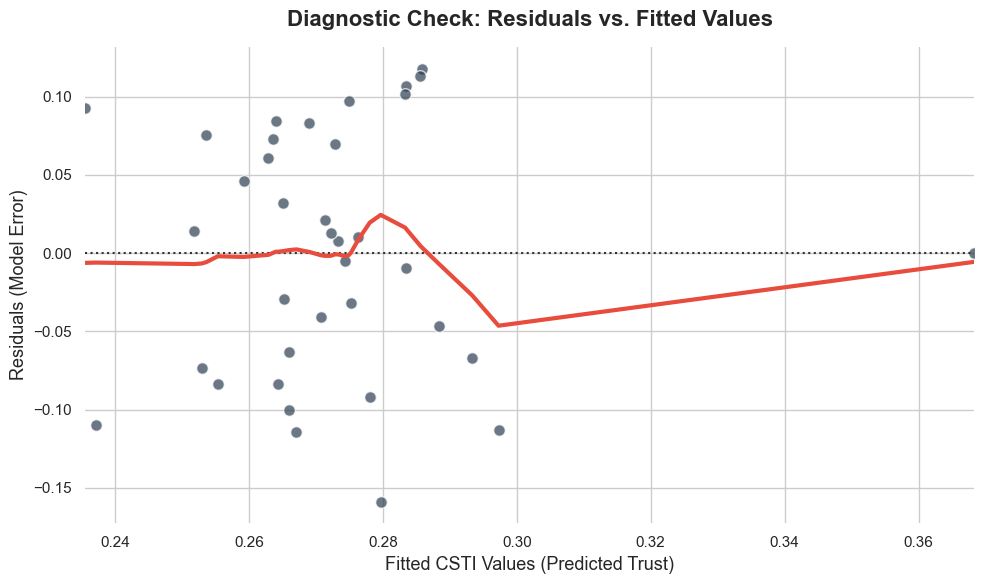

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

print("1. Loading Econometric Dataset...")

# Using a relative path to look one folder up, then into data/processed/
df = pd.read_csv("../data/processed/csti_master_dataset.csv")

# Cleaned any residual NaN placeholders just in case
df = df.dropna(subset=['CSTI', 'ln_Budget_i', 'State_Population'])

print("2. Preparing Variables for Regression...")
# Dependent Variable (Y): Citizen Security Trust Index
Y = df['CSTI']

# Created a logarithmic population control variable if not already present
df['ln_Pop_i'] = np.log(df['State_Population'])

# Independent Variables (X): Log of per-capita budget & Log of population
X = df[['ln_Budget_i', 'ln_Pop_i']]

# Added a constant (baseline intercept) to the model. 
X = sm.add_constant(X)

print("3. Fitting OLS Regression Model...")
# Ordinary Least Squares (OLS) Regression execution
model = sm.OLS(Y, X).fit()


# 4. PRINTED THE ACADEMIC SUMMARY
print("\n" + "="*78)
print("   SECURITY SECTOR ACCOUNTABILITY AND CITIZEN TRUST: OLS REGRESSION OUTPUT")
print("="*78)
print(model.summary())


# 5. DIAGNOSTIC VISUALIZATION
# ==========================================
# Plotting the residuals to check for homoskedasticity (a key OLS assumption)
plt.figure(figsize=(10, 6))
sns.residplot(
    x=model.fittedvalues, 
    y=model.resid, 
    lowess=True, 
    scatter_kws={'alpha': 0.7, 'edgecolor': 'w', 's': 70, 'color': '#2c3e50'}, 
    line_kws={'color': '#e74c3c', 'lw': 3}
)

plt.title('Diagnostic Check: Residuals vs. Fitted Values', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fitted CSTI Values (Predicted Trust)', fontsize=13)
plt.ylabel('Residuals (Model Error)', fontsize=13)
sns.despine(left=True, bottom=True)
plt.tight_layout()

print("\n4. Generating Diagnostic Plot...")
plt.show()